# STRATA · Exploración visual de la supervisión y de cuándo funciona cada estrategia

**Cuaderno EXPLORATORIO — NO canónico.** Trabajo en pruebas (rama `feat/quant-validation-panel`).
No es referencia de la memoria del TFG hasta validar. Sirve para **ver y decidir**.

**La pregunta:** ¿hay una supervisión *universal* del agente? ¿Por qué M10 a veces gana y a veces
pierde? ¿Podemos sacar una regla de *cuándo* funciona cada estrategia?

**Las 6 estrategias** (sobre la misma ventana de evaluación, ~250 días tras el burn-in del walk-forward):

| | Qué es |
|---|---|
| **M5** | el agente LLM solo (sin supervisar) |
| **M8** | STRATA actual: supervisa al agente (override-C hacia el régimen fiable) |
| **M10** | meta-learner XGBoost sobre 22 features (agente + STRATA) |
| **Régimen** | seguir el signo data-driven del régimen dominante (señal cruda de RAM) |
| **B&H** | comprar y mantener (siempre largo) |
| **ZeroR** | clase mayoritaria realizada (no-information-rate) |

Cifras leídas de `outputs/experiments/*.json` (auditados). Cada gráfica indica su fuente.

In [1]:
# --- Bootstrap raíz + carga de los JSON auditados ---
import os, sys, json, warnings
from pathlib import Path
_ROOT = Path.cwd()
while not (_ROOT / "config.py").exists() and _ROOT != _ROOT.parent:
    _ROOT = _ROOT.parent
os.chdir(_ROOT); sys.path.insert(0, str(_ROOT)); warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def J(name): return json.load(open(f"outputs/experiments/{name}.json"))
CL  = J("strategy_clustering")       # tabla 12x6 + naturaleza + clusters
ML  = J("meta_labeling_panel")       # pooled M8/M_meta vs M5/ZeroR (agente-céntrico)
SU  = J("strata_u_panel")            # STRATA-U (régimen al mando), 3 variantes
LEV = J("leverage_screen")["por_activo"]

PA = CL["por_activo"]; ASSETS = CL["meta"]["panel"]
STRATS = ["M5", "M8", "M10", "Régimen", "B&H", "ZeroR"]
COL = {"M5": "#9e9e9e", "M8": "#f0a830", "M10": "#2c7fb8", "Régimen": "#c0392b",
       "B&H": "#4caf50", "ZeroR": "#7b5cc4"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
print("activos:", len(ASSETS), "· ventana:", CL["meta"]["ventana"])
print("clusters (k):", CL["meta"]["k_elegido"], "· siluetas:", {k: round(v,2) for k,v in CL["meta"]["k_silueta"].items()})

activos: 12 · ventana: M10 walk-forward (~250 d tras burn-in 150)
clusters (k): 3 · siluetas: {'2': 0.42, '3': 0.45, '4': 0.34}


## §1. Tabla completa de estrategias (accuracy y Sharpe)

Mapa de calor de accuracy direccional (azul = mejor que el azar 0,5; rojo = peor) y de Sharpe.
**ZeroR** (clase mayoritaria) es el listón duro; entre las desplegables miramos M5/M8/M10/Régimen.

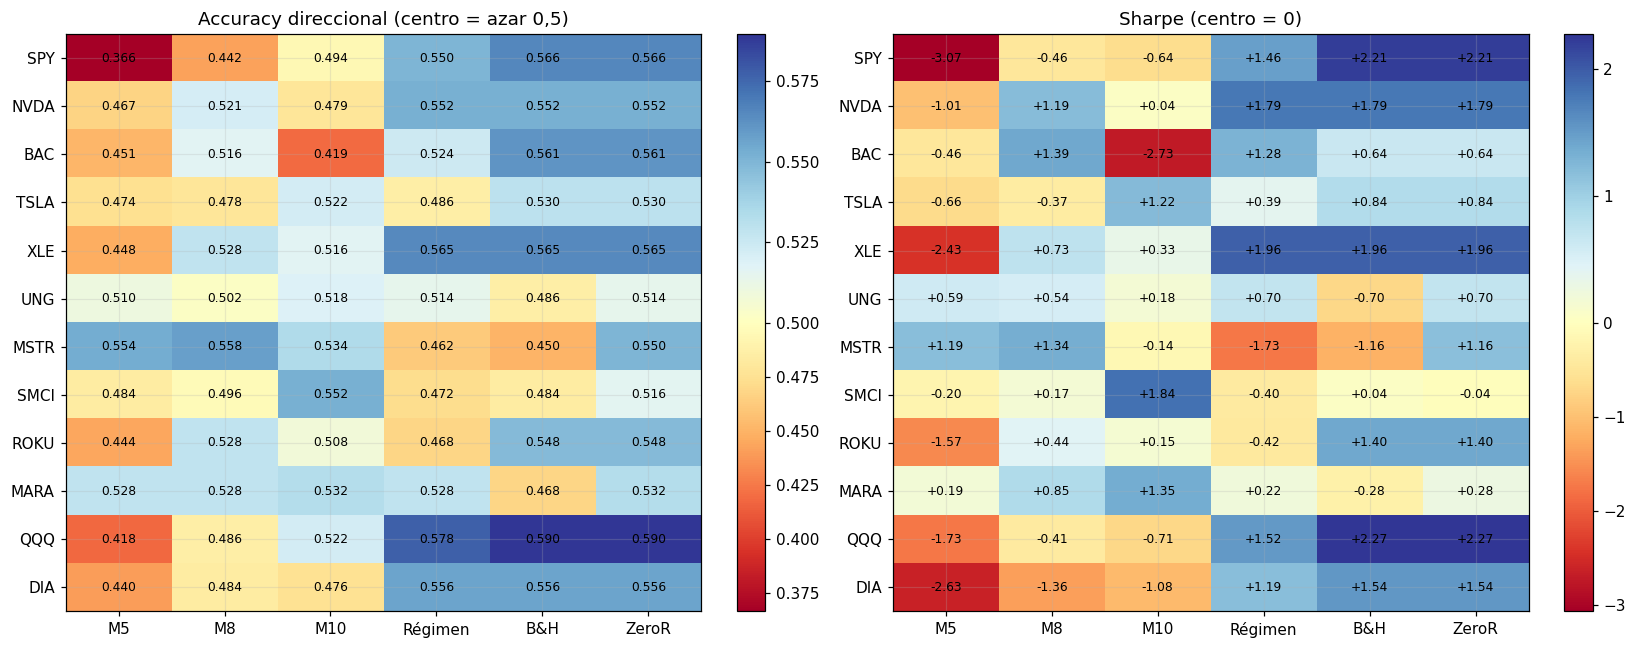

Fuente: strategy_clustering.json · ZeroR gana en accuracy casi siempre (es el NIR); entre desplegables, la mejor cambia por activo → esa es la clave.


In [2]:
acc = pd.DataFrame({s: {a: PA[a]["acc"][s] for a in ASSETS} for s in STRATS}).loc[ASSETS]
shp = pd.DataFrame({s: {a: PA[a]["sharpe"][s] for a in ASSETS} for s in STRATS}).loc[ASSETS]

def heatmap(ax, df, center, title, fmt):
    norm = TwoSlopeNorm(vcenter=center, vmin=df.values.min(), vmax=df.values.max())
    im = ax.imshow(df.values, cmap="RdYlBu", norm=norm, aspect="auto")
    ax.set_xticks(range(len(df.columns))); ax.set_xticklabels(df.columns, rotation=0)
    ax.set_yticks(range(len(df.index))); ax.set_yticklabels(df.index)
    for i in range(df.shape[0]):
        for j in range(df.shape[1]):
            ax.text(j, i, fmt.format(df.values[i, j]), ha="center", va="center", fontsize=8)
    ax.set_title(title); plt.colorbar(im, ax=ax, fraction=0.046)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
heatmap(ax[0], acc, 0.5, "Accuracy direccional (centro = azar 0,5)", "{:.3f}")
heatmap(ax[1], shp, 0.0, "Sharpe (centro = 0)", "{:+.2f}")
plt.tight_layout(); plt.show()
print("Fuente: strategy_clustering.json · ZeroR gana en accuracy casi siempre (es el NIR);"
      " entre desplegables, la mejor cambia por activo → esa es la clave.")

## §2. ¿La supervisión bate al AGENTE? (lo que el TFG debe demostrar)

Mirar M10 por activo (n≈250) engaña: gana/pierde por ruido. La señal aparece al **agrupar el panel**
(pooled, ~4.800 decisiones). Aquí: el valor añadido de la supervisión sobre el agente, ΔM8 = M8 − M5,
por activo; y el contraste **pooled** (clusterizado por fecha) de `meta_labeling_panel.json`.

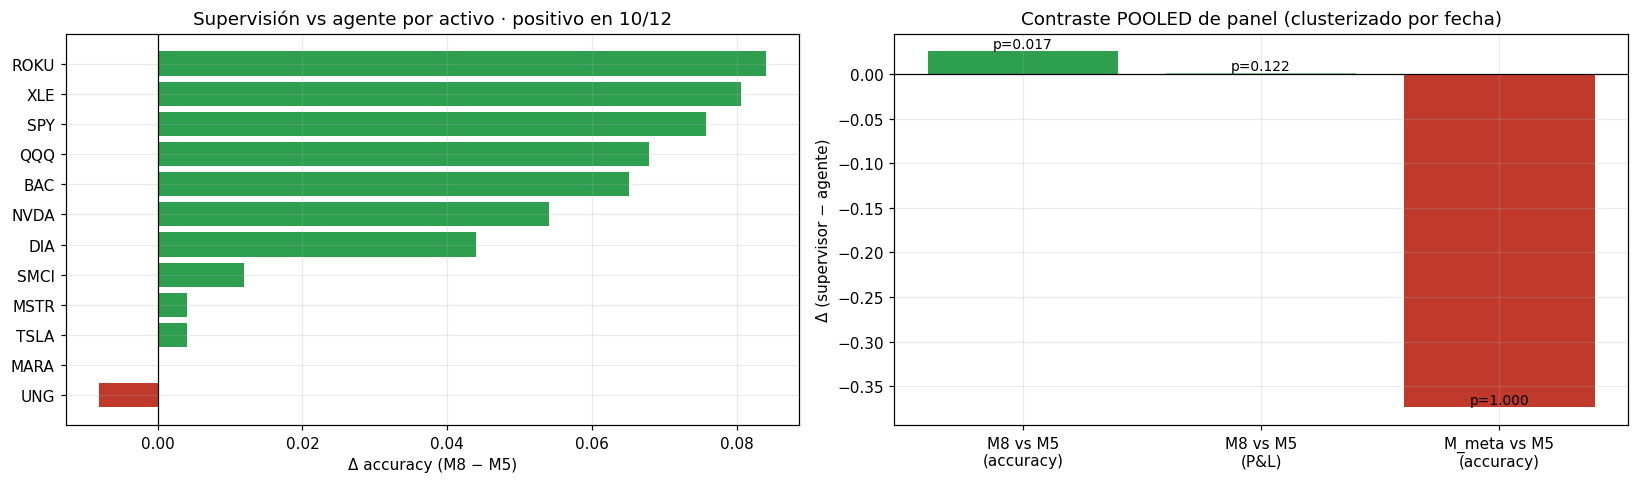

M8 vs M5 pooled accuracy: Δ=+0.0252, p=0.0165, IC95=[+0.0014,+0.0504] (n=4802, fechas=409)
Sharpe M8≥M5 en 11/12 (sign p= 0.0032 )
→ La supervisión (M8, agente-céntrica) BATE al agente de forma significativa a nivel de panel.


In [3]:
dM8 = pd.Series({a: PA[a]["acc"]["M8"] - PA[a]["acc"]["M5"] for a in ASSETS}).sort_values()
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].barh(dM8.index, dM8.values, color=np.where(dM8.values >= 0, "#2e9e4f", "#c0392b"))
ax[0].axvline(0, color="k", lw=0.8); ax[0].set_xlabel("Δ accuracy (M8 − M5)")
ax[0].set_title(f"Supervisión vs agente por activo · positivo en {int((dM8>0).sum())}/{len(dM8)}")

P = ML["pooled"]
labels = ["M8 vs M5\n(accuracy)", "M8 vs M5\n(P&L)", "M_meta vs M5\n(accuracy)"]
keys = ["M8_vs_M5_acc", "M8_vs_M5_pnl", "Mmeta_vs_M5_acc"]
deltas = [P[k]["delta"] for k in keys]; ps = [P[k]["p_greater"] for k in keys]
b = ax[1].bar(labels, deltas, color=["#2e9e4f", "#8fce9c", "#c0392b"])
ax[1].axhline(0, color="k", lw=0.8); ax[1].set_title("Contraste POOLED de panel (clusterizado por fecha)")
ax[1].set_ylabel("Δ (supervisor − agente)")
for bi, p in zip(b, ps): ax[1].text(bi.get_x()+bi.get_width()/2, bi.get_height(),
                                     f"p={p:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()
print(f"M8 vs M5 pooled accuracy: Δ={P['M8_vs_M5_acc']['delta']:+.4f}, p={P['M8_vs_M5_acc']['p_greater']:.4f}, "
      f"IC95=[{P['M8_vs_M5_acc']['ci_low']:+.4f},{P['M8_vs_M5_acc']['ci_high']:+.4f}] "
      f"(n={P['M8_vs_M5_acc']['n_pairs']}, fechas={P['M8_vs_M5_acc']['n_dates']})")
print("Sharpe M8≥M5 en", ML["obj1_vs_m5"]["m8_vs_m5"]["sharpe_ge"], "(sign p=", ML["obj1_vs_m5"]["m8_vs_m5"]["sign_p_sharpe"], ")")
print("→ La supervisión (M8, agente-céntrica) BATE al agente de forma significativa a nivel de panel.")

## §3. La naturaleza de los activos (leverage effect)

El *leverage effect* de Black (corr entre retorno y cambio de volatilidad; negativo = fuerte) mide si
el régimen del HMM puede ser direccional. Medido **solo en calibración** (ex-ante, sin look-ahead).

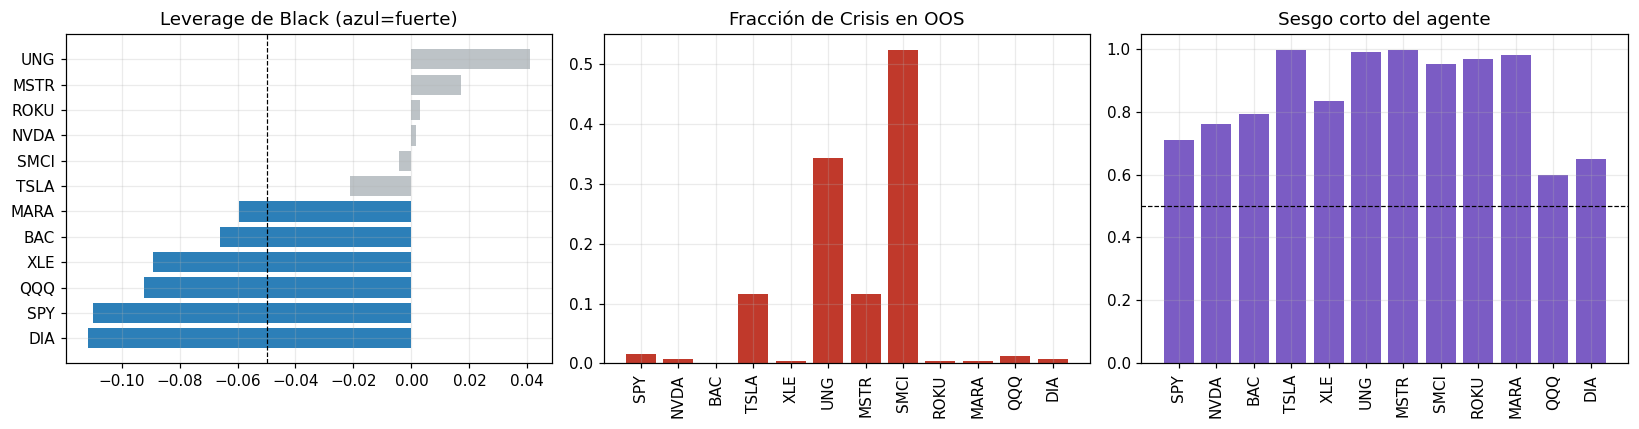

Fuente: strategy_clustering.json (nat). Leverage fuerte → régimen direccional; agente casi siempre corto.


In [4]:
lev = pd.Series({a: PA[a]["nat"]["leverage_corr"] for a in ASSETS}).sort_values()
crisis = pd.Series({a: PA[a]["nat"]["oos_crisis_frac"] for a in ASSETS})
short = pd.Series({a: PA[a]["nat"]["agent_short_frac"] for a in ASSETS})
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].barh(lev.index, lev.values, color=np.where(lev.values < -0.05, "#2c7fb8", "#bdc3c7"))
ax[0].axvline(-0.05, color="k", ls="--", lw=0.8); ax[0].set_title("Leverage de Black (azul=fuerte)")
ax[1].bar(crisis.index, crisis.values, color="#c0392b"); ax[1].set_title("Fracción de Crisis en OOS")
ax[1].tick_params(axis="x", rotation=90)
ax[2].bar(short.index, short.values, color="#7b5cc4"); ax[2].axhline(0.5, color="k", ls="--", lw=0.8)
ax[2].set_title("Sesgo corto del agente"); ax[2].tick_params(axis="x", rotation=90)
plt.tight_layout(); plt.show()
print("Fuente: strategy_clustering.json (nat). Leverage fuerte → régimen direccional; agente casi siempre corto.")

## §4. Clustering: ¿se distinguen grupos de activos?

KMeans sobre features de **naturaleza** (leverage, crisis_mean, fracción Crisis, vol, sesgo corto),
estandarizadas y **pre-especificadas** (anti-dragado). Proyección PCA 2D. n=12 → **exploratorio**.

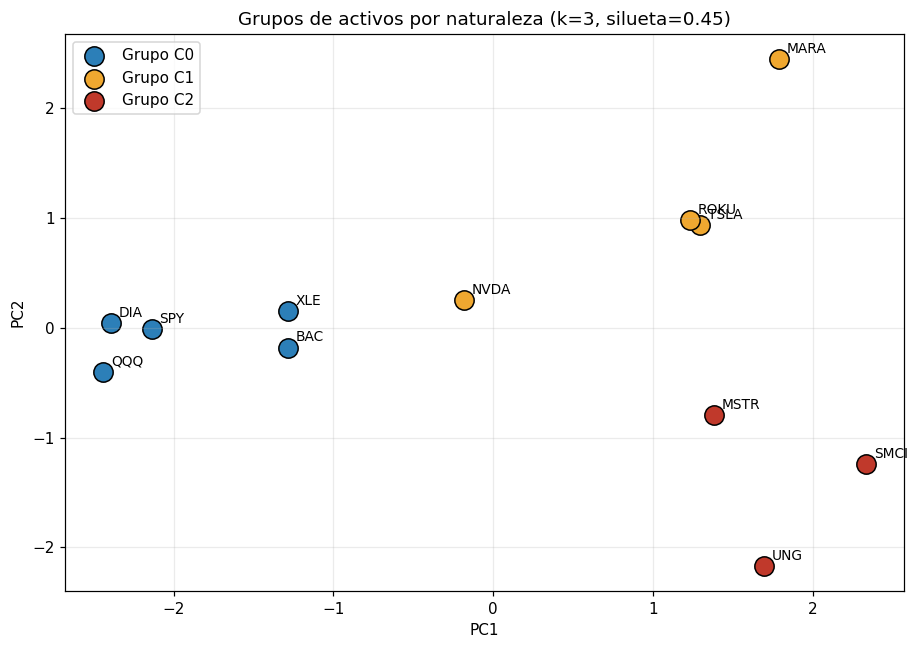

Grupos: {'C0': ['SPY', 'BAC', 'XLE', 'QQQ', 'DIA'], 'C1': ['NVDA', 'TSLA', 'ROKU', 'MARA'], 'C2': ['UNG', 'MSTR', 'SMCI']}


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import config
FEATS = CL["meta"]["cluster_features"]; k = CL["meta"]["k_elegido"]
X = np.array([[PA[a]["nat"][f] for f in FEATS] for a in ASSETS])
Xs = StandardScaler().fit_transform(X)
lab = KMeans(n_clusters=k, random_state=config.SEED, n_init=10).fit_predict(Xs)
pc = PCA(n_components=2).fit_transform(Xs)
cols = ["#2c7fb8", "#f0a830", "#c0392b", "#2e9e4f"]
fig, ax = plt.subplots(figsize=(8.5, 6))
for c in range(k):
    m = lab == c
    ax.scatter(pc[m, 0], pc[m, 1], s=160, color=cols[c], label=f"Grupo C{c}", edgecolor="black")
for i, a in enumerate(ASSETS):
    ax.annotate(a, (pc[i, 0], pc[i, 1]), fontsize=9, xytext=(5, 4), textcoords="offset points")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend()
ax.set_title(f"Grupos de activos por naturaleza (k={k}, silueta={CL['meta']['k_silueta'][str(k)]:.2f})")
plt.tight_layout(); plt.show()
for a, c in zip(ASSETS, lab): pass
print("Grupos:", {f"C{c}": [ASSETS[i] for i in range(len(ASSETS)) if lab[i]==c] for c in range(k)})

### §4b. Qué estrategia gana en cada grupo

Accuracy media por estrategia dentro de cada grupo. Aquí se ve el patrón: **la mejor estrategia
desplegable cambia según el tipo de activo.**

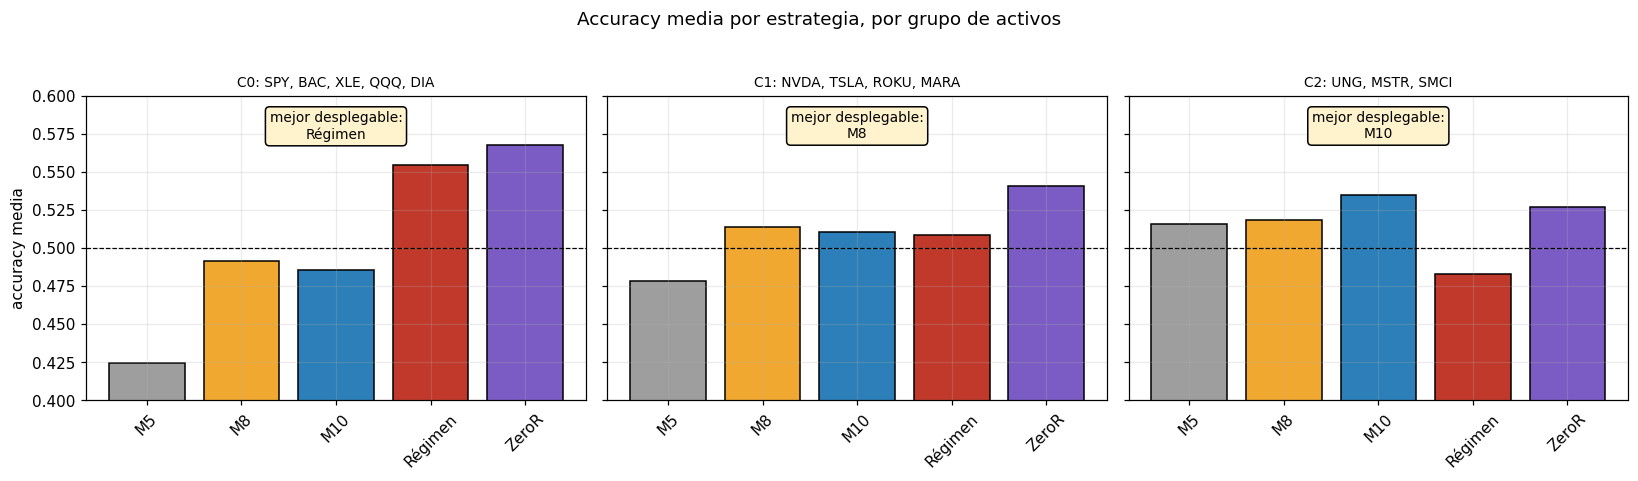

C0 ['SPY', 'BAC', 'XLE', 'QQQ', 'DIA']: mejor no-trivial acc=Régimen, sharpe=Régimen · ΔM8-M5=+0.067 ΔM10-M8=-0.006
C1 ['NVDA', 'TSLA', 'ROKU', 'MARA']: mejor no-trivial acc=M8, sharpe=M10 · ΔM8-M5=+0.035 ΔM10-M8=-0.004
C2 ['UNG', 'MSTR', 'SMCI']: mejor no-trivial acc=M10, sharpe=M8 · ΔM8-M5=+0.003 ΔM10-M8=+0.016


In [6]:
CLUS = CL["clusters"]
fig, axes = plt.subplots(1, len(CLUS), figsize=(5*len(CLUS), 4.2), sharey=True)
if len(CLUS) == 1: axes = [axes]
for ax, (cname, d) in zip(axes, CLUS.items()):
    ss = ["M5", "M8", "M10", "Régimen", "ZeroR"]
    vals = [d["acc_media"][s] for s in ss]
    ax.bar(ss, vals, color=[COL[s] for s in ss], edgecolor="black")
    ax.axhline(0.5, color="k", ls="--", lw=0.8)
    ax.set_title(f"{cname}: {', '.join(d['activos'])}", fontsize=9)
    ax.set_ylim(0.40, 0.60); ax.tick_params(axis="x", rotation=45)
    ax.annotate(f"mejor desplegable:\n{d['mejor_acc_no_trivial']}", (0.5, 0.95),
                xycoords="axes fraction", ha="center", va="top", fontsize=9,
                bbox=dict(boxstyle="round", fc="#fff3cd"))
axes[0].set_ylabel("accuracy media")
plt.suptitle("Accuracy media por estrategia, por grupo de activos", y=1.03)
plt.tight_layout(); plt.show()
for cname, d in CLUS.items():
    print(f"{cname} {d['activos']}: mejor no-trivial acc={d['mejor_acc_no_trivial']}, "
          f"sharpe={d['mejor_sharpe_no_trivial']} · ΔM8-M5={d['delta_M8_M5_acc']:+.3f} ΔM10-M8={d['delta_M10_M8_acc']:+.3f}")

## §5. ¿Y si redefinimos el supervisor? (contraste exploratorio)

STRATA-U pone el régimen+vol al mando (deja de ser "supervisión del agente"). Cobertura: en cuántos
de los 12 bate a M5 y a ZeroR. Se muestra para contraste — **el deliverable fiel sigue siendo M8.**

In [7]:
rows = []
for mode, pm in SU["por_modo"].items():
    rows.append({"variante": mode,
                 "acc≥M5": pm["obj1_m5"]["acc_ge"], "Sharpe≥M5": pm["obj1_m5"]["sharpe_ge"],
                 "pooled acc vs M5 p": pm["pooled"]["acc_vs_m5"]["p_greater"],
                 "Sharpe>ZeroR": f'{pm["obj2_zeror"]["sharpe"]}/{SU["meta"]["n_activos"]}',
                 "Calmar>ZeroR": f'{pm["obj2_zeror"]["calmar"]}/{SU["meta"]["n_activos"]}',
                 "acc>ZeroR": f'{pm["obj2_zeror"]["acc"]}/{SU["meta"]["n_activos"]}'})
display(pd.DataFrame(rows).set_index("variante"))
print("Las 3 variantes baten a M5 (pooled significativo) pero NINGUNA bate a ZeroR → ZeroR (NIR) no es")
print("batible por una estrategia causal en este OOS. M8 (agente-céntrico) es la conclusión fiel.")

,acc≥M5,Sharpe≥M5,pooled acc vs M5 p,Sharpe>ZeroR,Calmar>ZeroR,acc>ZeroR
variante,,,,,,
regime_flip,9/12,10/12,0.0000,3/12,6/12,0/12
risk_overlay,9/12,9/12,0.0005,3/12,7/12,0/12
trend,9/12,9/12,0.0005,3/12,7/12,0/12


Las 3 variantes baten a M5 (pooled significativo) pero NINGUNA bate a ZeroR → ZeroR (NIR) no es
batible por una estrategia causal en este OOS. M8 (agente-céntrico) es la conclusión fiel.


## §6. Conclusión y regla candidata

**1) La supervisión bate al agente, universal y significativo (pooled).** M8 (agente-céntrico): accuracy
pooled **+2,5 pp, p=0,017**; Sharpe mejor en **11/12** activos (p=0,003). *Esa es la conclusión fiel al TFG.*

**2) M10 no es universal — y no debe serlo.** Es el control de universalidad (un ML potente no bate a la
regla): por eso gana/pierde por activo. Lo que importa es **dónde** gana cada estrategia.

**3) La regla candidata (hipótesis pre-registrable, NO probada; n=12 exploratorio):** enrutar la
supervisión por la **naturaleza del activo, medible ex-ante** (leverage de Black + fracción de Crisis):

| Grupo | Naturaleza | Mejor supervisión desplegable |
|---|---|---|
| **C0** índices/ETF leverage fuerte | leverage ≪ 0, poca Crisis | **Régimen / M8** (la supervisión rescata al agente +6,7 pp) |
| **C1** acciones volátiles leverage débil | leverage ≈ 0, vol alta | **M8** (la regla) |
| **C2** leverage inverso + mucha Crisis + agente muy corto | leverage > 0 | **M10** (el régimen falla; el meta-learner monta el sesgo corto) |

**4) A ZeroR (no-information-rate) no se le gana** de forma causal en este OOS con tendencia — límite honesto.

**Avisos:** n=12 → clustering y regla son **exploratorios/hipótesis**, no confirmatorios; ZeroR es el listón
de accuracy; el agente solo existe en OOS post-2024-10. Promover a la memoria solo tras validar.

In [8]:
# --- Auto-test: las cifras del cuaderno son trazables a los JSON auditados ---
assert ML["pooled"]["M8_vs_M5_acc"]["p_greater"] < 0.05, "M8 vs M5 pooled no significativo?"
assert CL["meta"]["k_elegido"] in (2, 3, 4)
assert len(ASSETS) == 12
print("AUTO-TEST OK · cifras desde outputs/experiments/*.json (strategy_clustering, meta_labeling_panel, strata_u_panel)")
print("M8 bate al agente (pooled p={:.3f}); grupos={}".format(
    ML["pooled"]["M8_vs_M5_acc"]["p_greater"], {c: d["activos"] for c, d in CL["clusters"].items()}))

AUTO-TEST OK · cifras desde outputs/experiments/*.json (strategy_clustering, meta_labeling_panel, strata_u_panel)
M8 bate al agente (pooled p=0.017); grupos={'C0': ['SPY', 'BAC', 'XLE', 'QQQ', 'DIA'], 'C1': ['NVDA', 'TSLA', 'ROKU', 'MARA'], 'C2': ['UNG', 'MSTR', 'SMCI']}
